In [141]:
import networkx as nx
import numpy as np 
import matplotlib.pyplot as plt
import csv 
import statistics
import random

In [225]:
G = nx.DiGraph()

with open('data/rede1_duas_comunidades.csv') as f: 
    linha = csv.reader(f, delimiter=',')

    for li in linha: 
        u, v = int(li[0]), int(li[1])
        G.add_edge(u, v)

In [230]:
def plotar_grafo(G, savefig = False):
    plt.figure(figsize=(8, 6))
    pos = nx.circular_layout(G)
    rotulos = nx.get_node_attributes(G, name='rotulo')
    nx.draw(G, labels=rotulos, pos = pos, node_size=500, node_color="#cca752", alpha=0.85)

    if savefig == True: 
        plt.savefig('results/label_prop.png', dpi = 200)

    plt.show()


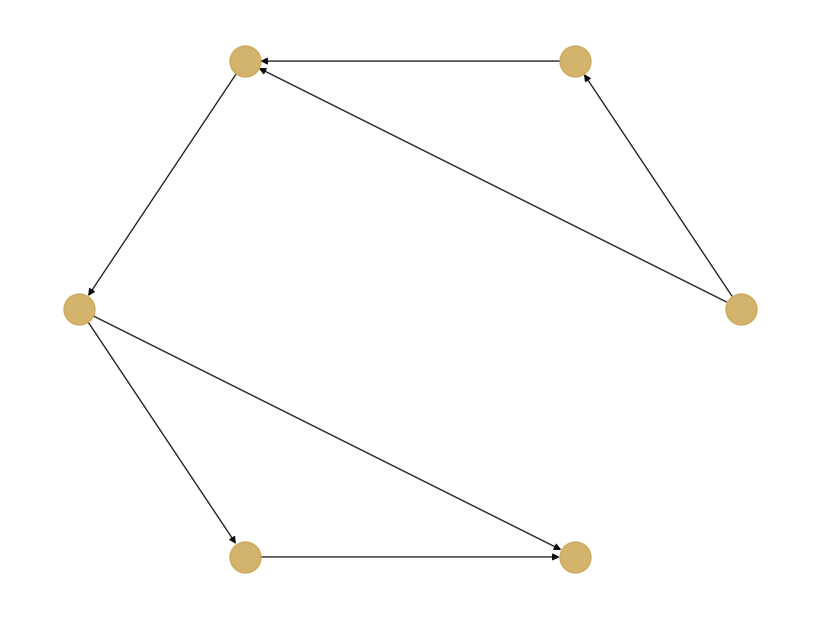

In [231]:
plotar_grafo(G)

In [220]:
def calc_moda(listaVizinhos): 
    contagem = {}

    for valor in listaVizinhos:
        contagem[valor] = contagem.get(valor, 0) + 1

    maior_frequencia = max(contagem.values())

    modas = [valor for valor, frequencia in contagem.items() if frequencia == maior_frequencia]

    return random.choice(modas)

In [234]:
def LabelProp(G, maxIt=10): 
    N = G.number_of_nodes()

    #add o proprio vertice como rotulo inicial como propriedades de vi \in G
    for i in G.nodes: 
        G.nodes[i]['rotulo'] = i

    
    mudou = True 
    it = 0

    while it < maxIt and mudou == True:
        plotar_grafo(G)
        mudou = False
        ordemVisita = np.array(list(G.nodes()))                 #preciso disso aqui pq o shuffle altera o vetor 
        np.random.shuffle(ordemVisita)

        for u in ordemVisita:
            vizinhos = list(G.neighbors(u))
            #print(type(vizinhos))
            

            if len(vizinhos) > 0: 
                rotulosVizinhos = [G.nodes[i]['rotulo'] for i in vizinhos]
                novoRotulo = calc_moda(rotulosVizinhos)

                if novoRotulo != G.nodes[u]['rotulo']: 
                    G.nodes[u]['rotulo'] = novoRotulo
                    mudou = True
        
                

        it += 1





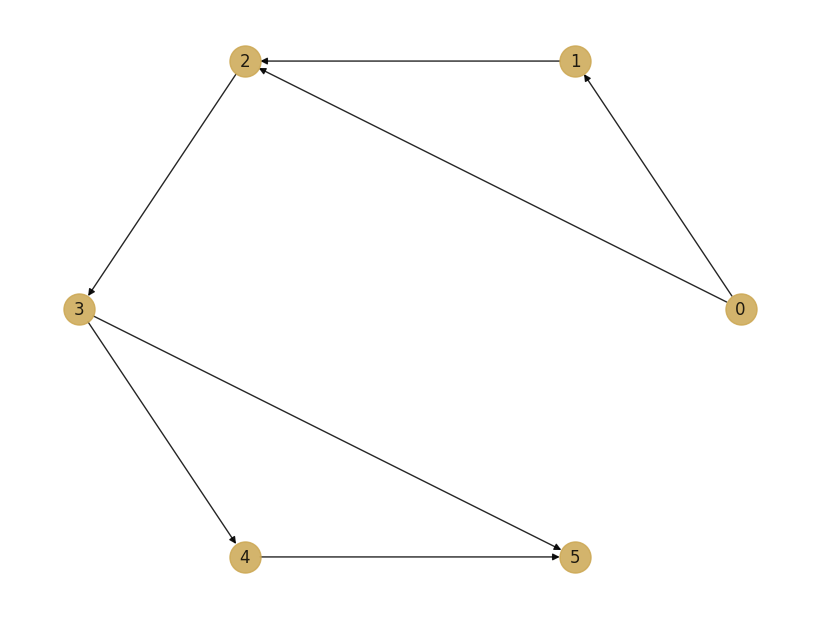

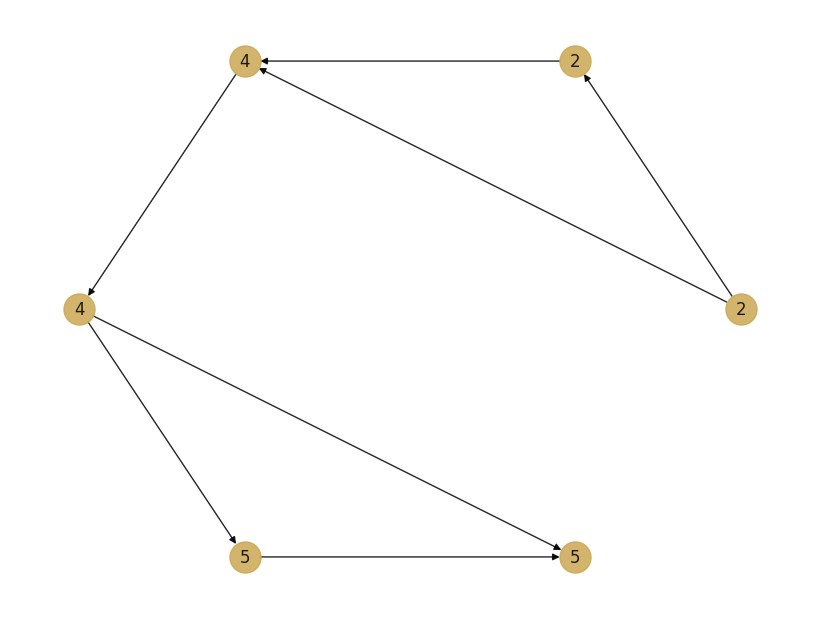

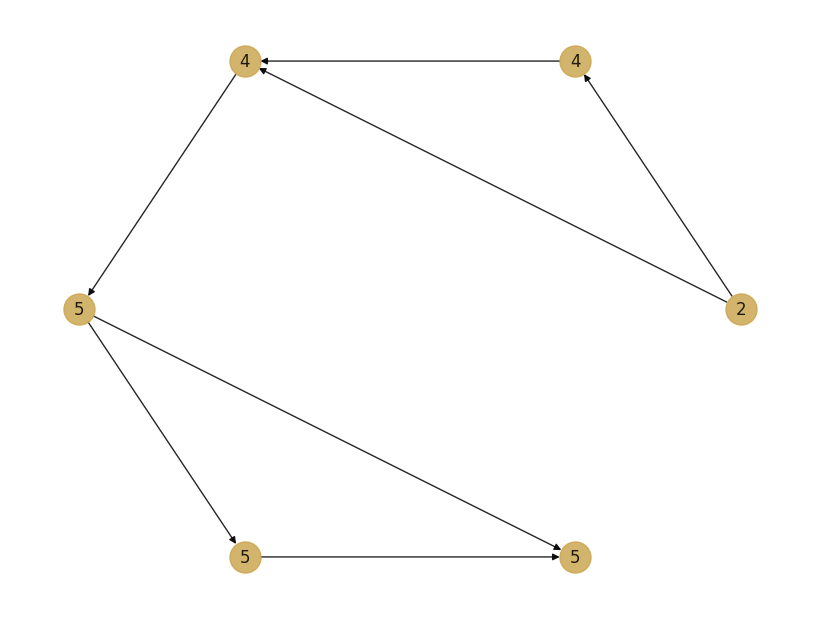

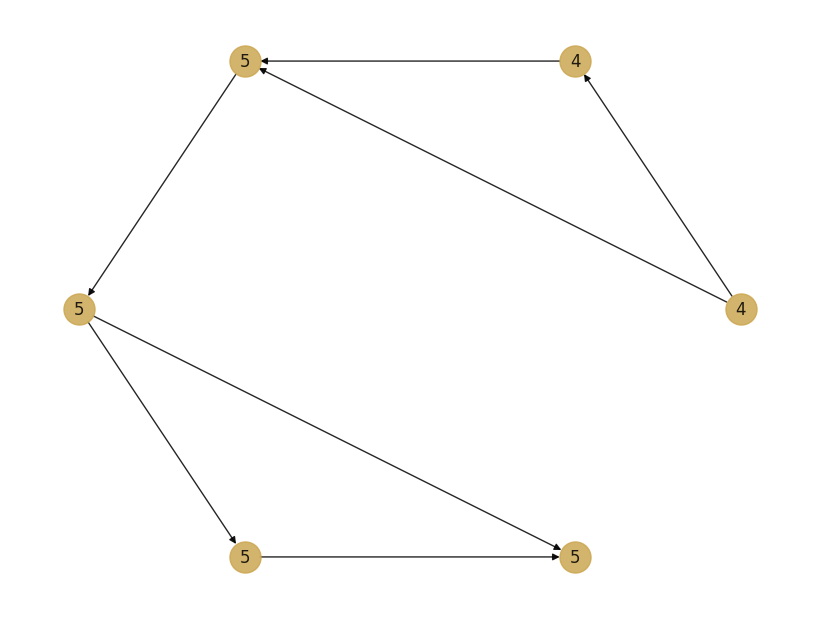

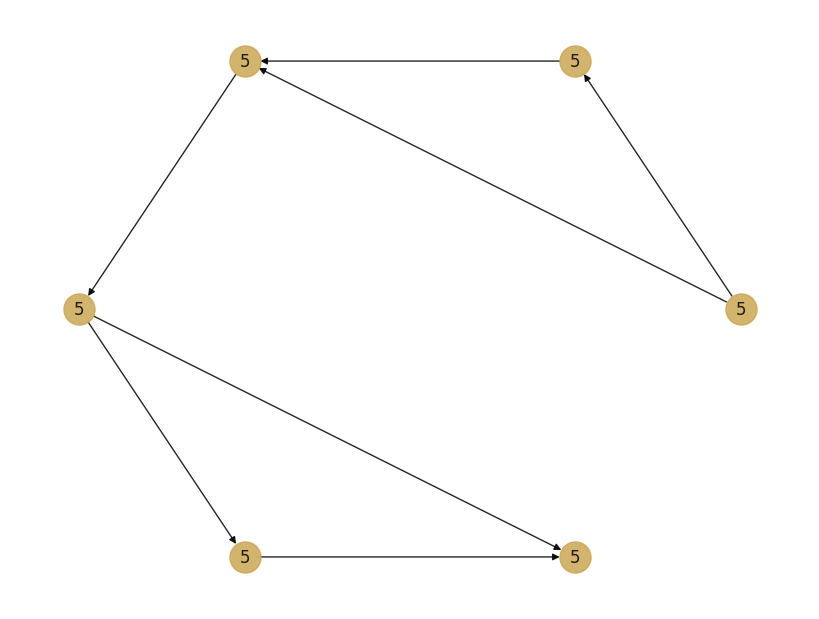

In [235]:
LabelProp(G, 20)
